## Why EDA (Exploratory Data Analysis) Matters

In a machine learning project, **EDA (Exploratory Data Analysis)** is often more important than training the first model because it helps you understand:

- **Rating distribution** – Are users generous or strict in giving ratings?
- **User activity** – Which users rate the most movies?
- **Movie popularity** – Which movies receive the highest number of ratings?
- **Missing values** – Are there any incomplete records in the dataset?
- **Outliers** – Are there unusual values that may affect model performance?
- **Feature relationships** – How do different variables interact with each other?
- **Correlations** – Which features are strongly related to the target variable?
- **Model errors after prediction** – Where and why does the model make mistakes?

Understanding these aspects helps improve data quality, feature engineering, model selection, and overall predictive performance.

In [133]:
import pandas as pd

ratings = pd.read_csv(
    "ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "ml-1m/movies.dat",
    sep="::",
    engine="python",
    encoding="latin1",
    names=["movie_id", "title", "genres"]
)

users = pd.read_csv(
    "ml-1m/users.dat",
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zipcode"]
)

==========================|Data Shape|=========================

In [134]:
print("Ratings Shape :", ratings.shape)
print("Movies Shape  :", movies.shape)
print("Users Shape   :", users.shape)

Ratings Shape : (1000209, 4)
Movies Shape  : (3883, 3)
Users Shape   : (6040, 5)


==========================|First few rows|=========================

In [135]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [161]:
ratings.tail()

,user_id,movie_id,rating,timestamp
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648
1000208,6040,1097,4,956715569


In [136]:
movies.head()


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [137]:
users.head()

,user_id,gender,age,occupation,zipcode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


==========================|Data Types|=========================

In [138]:
ratings.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [139]:
movies.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  3883 non-null   int64 
 1   title     3883 non-null   object
 2   genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [140]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     6040 non-null   int64 
 1   gender      6040 non-null   object
 2   age         6040 non-null   int64 
 3   occupation  6040 non-null   int64 
 4   zipcode     6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


==========================|Missing Values|=========================

In [141]:
ratings.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [142]:
movies.isnull().sum()

movie_id    0
title       0
genres      0
dtype: int64

In [143]:

users.isnull().sum()

user_id       0
gender        0
age           0
occupation    0
zipcode       0
dtype: int64

==========================|Statistical Summary|=========================

In [144]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


==========================|Unique counts|=========================

In [145]:
print("Unique Users :", ratings['user_id'].nunique())
print("Unique Movies:", ratings['movie_id'].nunique())

Unique Users : 6040
Unique Movies: 3706


==========================|Most Rated Movies|=========================

In [146]:
movie_counts = ratings.groupby('movie_id')['rating'].count()

movie_counts.sort_values(ascending=False).head(10)

movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
Name: rating, dtype: int64

==========================|Most Active Users|=========================

In [147]:
user_counts = ratings.groupby('user_id')['rating'].count()

user_counts.sort_values(ascending=False).head(10)

user_id
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
Name: rating, dtype: int64

==========================|Merge Dataset|=========================

In [148]:
data = ratings.merge(movies,on='movie_id')
data = data.merge(users,on='user_id')
data.head()

,user_id,movie_id,rating,timestamp,title,genres,gender,age,occupation,zipcode
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama,F,1,10,48067
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical,F,1,10,48067
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance,F,1,10,48067
3,1,3408,4,978300275,Erin Brockovich (2000),Drama,F,1,10,48067
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy,F,1,10,48067


**==========================|EDA Using Plots|=========================**


==========================|Rating Distribution|=========================

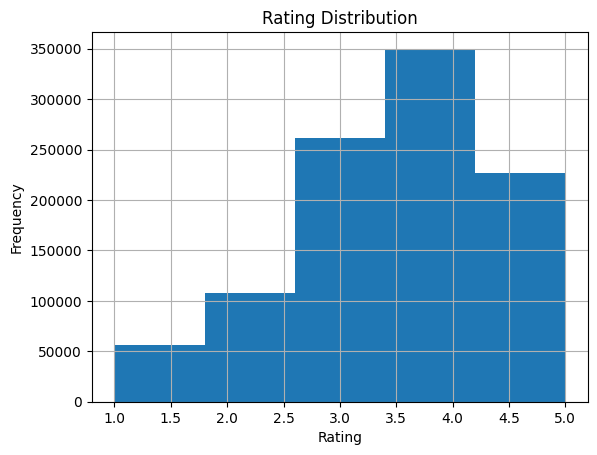

In [149]:
import matplotlib.pyplot as plt

ratings['rating'].hist(bins=5)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

==========================|User Activity Distribution|=========================

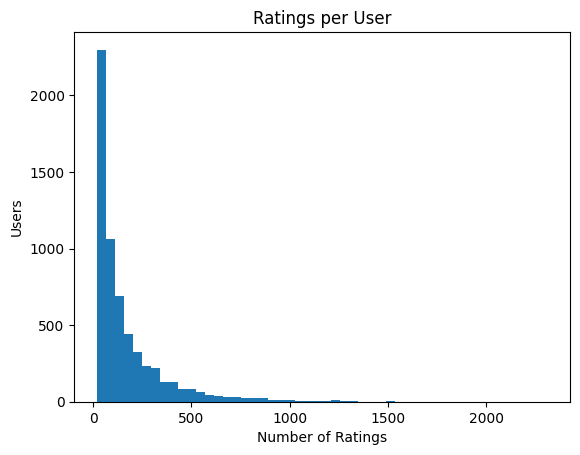

In [150]:
user_activity = ratings.groupby('user_id').size()

plt.hist(user_activity,bins=50)

plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.show()

==========================|Movie Popularity|=========================

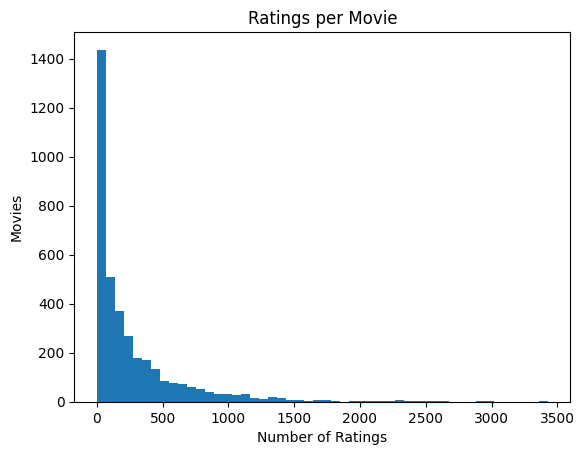

In [151]:
movie_popularity = ratings.groupby('movie_id').size()

plt.hist(movie_popularity,bins=50)

plt.title("Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Movies")
plt.show()

==========================|Gender Distribution|=========================

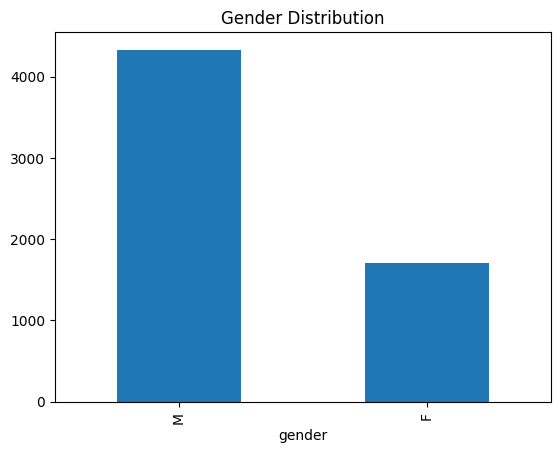

In [152]:
users['gender'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.show()

==========================|Age Distribution|=========================

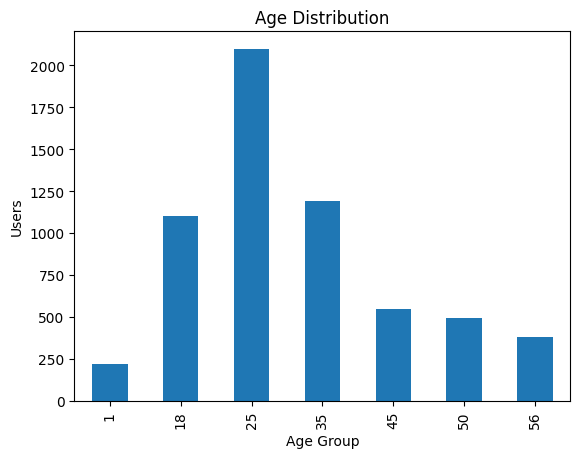

In [153]:
users['age'].value_counts().sort_index().plot(kind='bar')

plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Users")
plt.show()

==========================|Average Rating by Gender|=========================

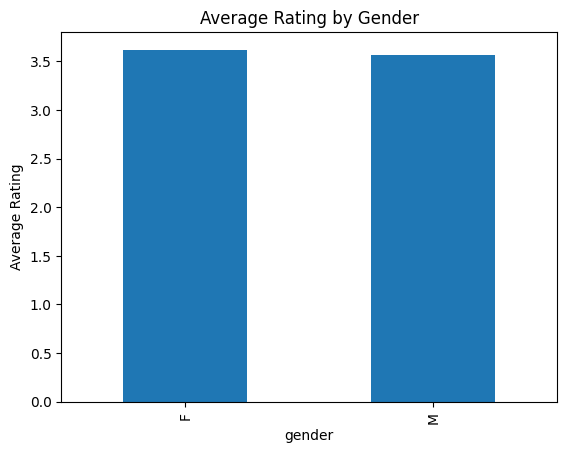

In [154]:
gender_rating = data.groupby('gender')['rating'].mean()

gender_rating.plot(kind='bar')

plt.title("Average Rating by Gender")
plt.ylabel("Average Rating")
plt.show()

==========================|Top 10 Most Rated Movies|=========================

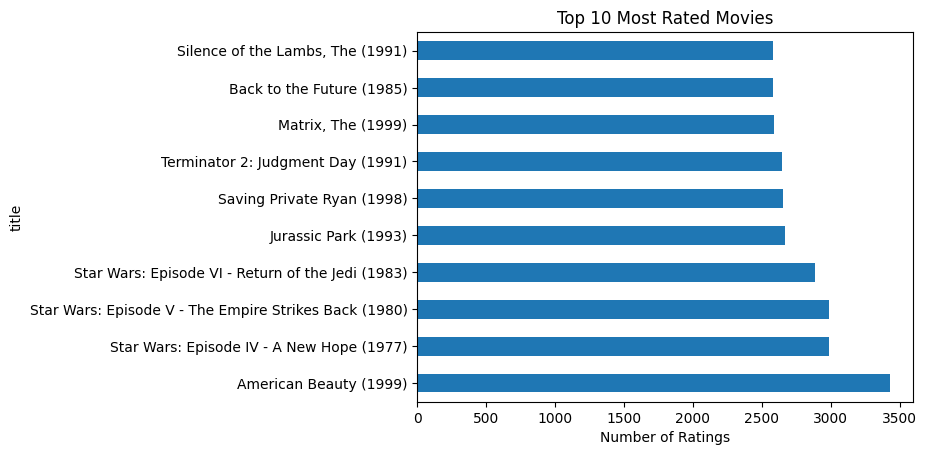

In [155]:
top_movies = data.groupby('title')['rating'].count()

top_movies = top_movies.sort_values(ascending=False).head(10)

top_movies.plot(kind='barh')

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.show()

==========================|Average Rating of Popular Movies|=========================

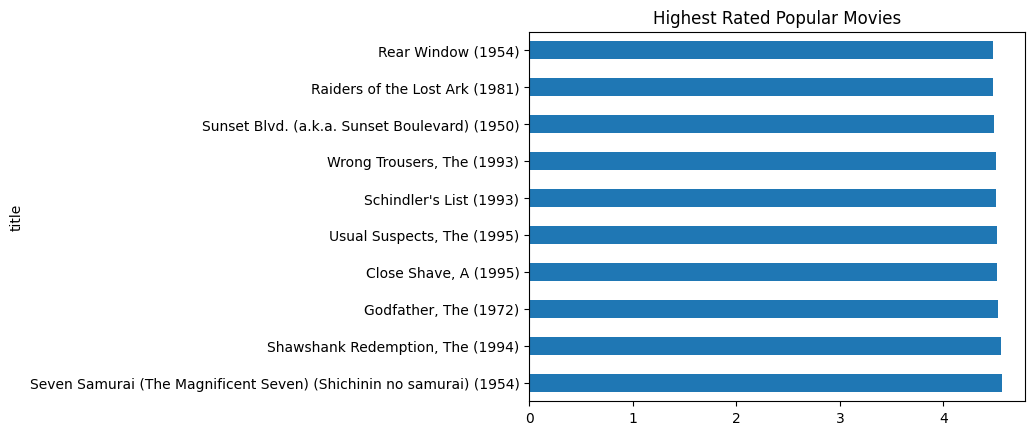

In [156]:
movie_stats = data.groupby('title')['rating'].agg(['mean','count'])

popular = movie_stats[movie_stats['count'] > 100]

popular['mean'].sort_values(ascending=False).head(10).plot(kind='barh')

plt.title("Highest Rated Popular Movies")
plt.show()

==========================|Genre Frequency|=========================

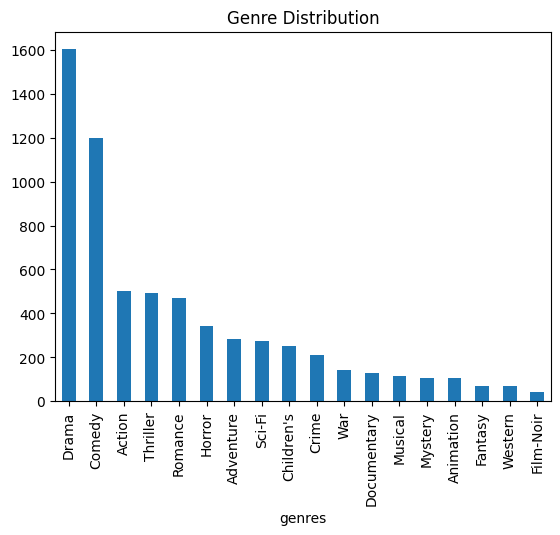

In [157]:
genres = movies['genres'].str.split('|').explode()

genres.value_counts().plot(kind='bar')

plt.title("Genre Distribution")
plt.show()

==========================|Correlation Heatmap|=========================

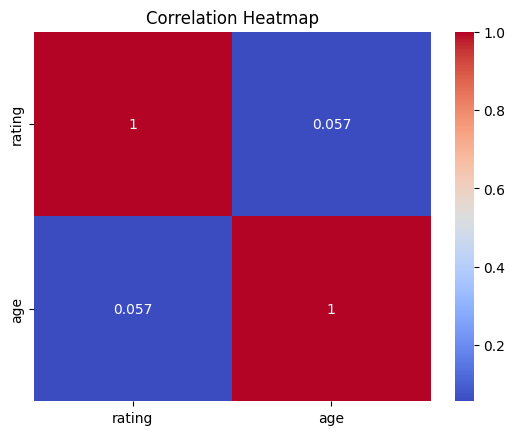

In [158]:
import seaborn as sns

numeric = data[['rating','age']]

sns.heatmap(numeric.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

** ==========================|Left Things|========================= **

In [159]:
==========================|Unique Value Analysis|=========================

SyntaxError: invalid syntax (423733413.py, line 1)

In [ ]:
ratings.nunique()


user_id        6040
movie_id       3706
rating            5
timestamp    458455
dtype: int64

In [ ]:
movies.nunique()


movie_id    3883
title       3883
genres       301
dtype: int64

In [ ]:
users.nunique()

user_id       6040
gender           2
age              7
occupation      21
zipcode       3439
dtype: int64

==========================|Missing Value Percentage|=========================

In [ ]:
(ratings.isnull().sum()/len(ratings))*100

user_id      0.0
movie_id     0.0
rating       0.0
timestamp    0.0
dtype: float64

==========================|Median Analysis|=========================

In [ ]:
ratings.median(numeric_only=True)

user_id           3070.0
movie_id          1835.0
rating               4.0
timestamp    973018006.0
dtype: float64

==========================|Mode Analysis|=========================

In [ ]:
ratings.mode()

,user_id,movie_id,rating,timestamp
0,4169,2858,4,975528402


==========================|Variance Analysis|=========================

In [ ]:
ratings.var(numeric_only=True)

user_id      2.987410e+06
movie_id     1.201305e+06
rating       1.247917e+00
timestamp    1.476847e+14
dtype: float64

==========================|Standard Deviation|=========================

In [ ]:
ratings.std(numeric_only=True)

user_id      1.728413e+03
movie_id     1.096041e+03
rating       1.117102e+00
timestamp    1.215256e+07
dtype: float64

==========================|Quantiles|=========================

In [ ]:
ratings['rating'].quantile(
    [.25,.50,.75,.90,.95,.99]
)

0.25    3.0
0.50    4.0
0.75    4.0
0.90    5.0
0.95    5.0
0.99    5.0
Name: rating, dtype: float64

==========================|Interquartile Range (IQR)|=========================

In [ ]:
Q1 = ratings['rating'].quantile(.25)
Q3 = ratings['rating'].quantile(.75)

IQR = Q3-Q1
IQR

np.float64(1.0)

==========================|Skewness Analysis|=========================

In [ ]:
ratings['rating'].skew()

np.float64(-0.5536098874940055)

==========================|Kurtosis Analysis|=========================

In [ ]:
ratings['rating'].kurt()

np.float64(-0.3519708031404196)

** ==========================|Normality Testing|========================= **

==========================|Shapiro-Wilk Test|=========================

In [ ]:
from scipy.stats import shapiro

sample_ratings = ratings['rating'].sample(
    5000,
    random_state=42
)

stat, p = shapiro(sample_ratings)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 0.8875469418434169
P-value: 3.3182683778611756e-51


==========================|D'Agostino Test|=========================

In [ ]:
from scipy.stats import normaltest

stat, p = normaltest(sample_ratings)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 253.0444107187255
P-value: 1.1274683886298885e-55


==========================|Anderson-Darling Test|=========================

In [ ]:
from scipy.stats import anderson

result = anderson(sample_ratings)

print(result)

AndersonResult(statistic=np.float64(206.5063835877063), critical_values=array([0.576, 0.655, 0.786, 0.917, 1.091]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(3.599), scale=np.float64(1.1036496765376702))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


==========================|Outlier Detection Using IQR|=========================

In [ ]:
user_counts = ratings.groupby(
    'user_id'
).size()

user_counts.sort_values(ascending=False).head(10)

user_id
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
889     1518
3618    1344
2063    1323
1150    1302
1015    1286
dtype: int64

In [ ]:
Q1 = user_counts.quantile(0.25)
Q3 = user_counts.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

user_outliers = user_counts[
    (user_counts < lower)
    | (user_counts > upper)
]

print(user_outliers.head())
print(user_outliers.shape)

user_id
48     598
53     684
62     498
117    505
123    608
dtype: int64
(475,)


==========================|Movie Popularity Outliers|=========================

In [ ]:
movie_counts = ratings.groupby(
    'movie_id'
).size()
movie_counts.sort_values(ascending=False).head(10)

movie_id
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
dtype: int64

In [ ]:
Q1 = movie_counts.quantile(0.25)
Q3 = movie_counts.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

movie_outliers = movie_counts[
    (movie_counts < lower)
    | (movie_counts > upper)
]

print(movie_outliers.head())
print(movie_outliers.shape)

movie_id
1     2077
6      940
10     888
11    1033
17     835
dtype: int64
(296,)


==========================|Outlier Detection Using Z-score|=========================

--------------------------|User Activity|-------------------------

In [ ]:
from scipy.stats import zscore

user_z = zscore(user_counts)

outliers = user_counts[
    abs(user_z) > 3
]

print(outliers.head())

user_id
195    822
216    794
245    764
302    788
329    764
dtype: int64


--------------------------|Movie Popularity|-------------------------

In [ ]:
movie_z = zscore(movie_counts)

outliers = movie_counts[
    abs(movie_z) > 3
]

print(outliers.head())

movie_id
1      2077
32     1511
34     1751
50     1783
110    2443
dtype: int64


==========================|Correlation Matrix|=========================

In [ ]:
data[['rating','age']].corr()

,rating,age
rating,1.000000,0.056869
age,0.056869,1.000000


==========================|Covariance Matrix|=========================

In [ ]:
data[['rating','age']].cov()

,rating,age
rating,1.247917,0.746581
age,0.746581,138.109094


==========================|Crosstab Statistics|=========================

In [ ]:
gender_occ = pd.crosstab(
    data['gender'],
    data['occupation']
)

gender_occ

occupation,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
gender,,,,,,,,,,,,,,,,,,,,,
F,32945,32533,16050,14325,32464,3905,14979,17967,636,10554,...,2643,6804,2799,11989,4198,7439,7649,414,3473,15691
M,97554,52818,34018,17298,98568,17945,22226,87458,2070,791,...,17920,50410,10955,37120,18753,38582,65167,11672,11431,44706


==========================|Group Statistics|=========================

--------------------------|Mean Rating by Gender|-------------------------

In [ ]:
data.groupby(
    'gender'
)['rating'].mean()

gender
F    3.620366
M    3.568879
Name: rating, dtype: float64

--------------------------|Median Rating by Gender|-------------------------

In [ ]:
data.groupby(
    'gender'
)['rating'].median()

gender
F    4.0
M    4.0
Name: rating, dtype: float64

--------------------------|Standard Deviation by Gender|-------------------------

In [ ]:
data.groupby(
    'gender'
)['rating'].std()

gender
F    1.111228
M    1.118724
Name: rating, dtype: float64

==========================|Genre Statistics|=========================

In [ ]:
genre_rating = data.groupby(
    'genres'
)['rating'].mean()

genre_rating.sort_values(
    ascending=False
).head()

genres
Animation|Comedy|Thriller    4.473837
Sci-Fi|War                   4.449890
Animation                    4.394336
Film-Noir|Mystery            4.367424
Adventure|War                4.346107
Name: rating, dtype: float64

==========================|Time-Based Statistics|=========================

In [ ]:
ratings['Date'] = pd.to_datetime(
    ratings['timestamp'],
    unit='s'
)

--------------------------|Ratings per year|-------------------------

In [ ]:
ratings.groupby(
    ratings['Date'].dt.year
).size()

Date
2000    904757
2001     68058
2002     24046
2003      3348
dtype: int64

--------------------------|Avg Ratings per year|-------------------------

In [ ]:
ratings.groupby(
    ratings['Date'].dt.year
)['rating'].mean()

Date
2000    3.590392
2001    3.512254
2002    3.458829
2003    3.486559
Name: rating, dtype: float64

 ==========================|Grapicl EDA Missing|========================= 

==========================|KDE Plot|=========================

<Axes: xlabel='rating', ylabel='Density'>

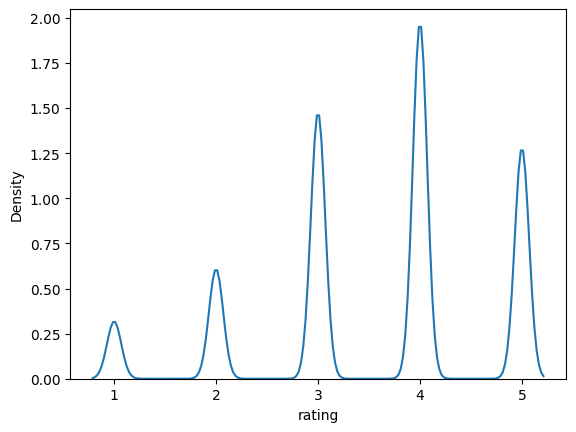

In [ ]:
sns.kdeplot(
    ratings['rating']
)

==========================|Rating Boxplot|=========================

<Axes: xlabel='rating'>

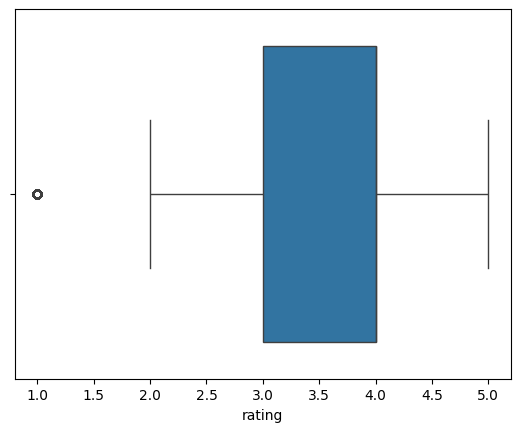

In [ ]:
sns.boxplot(
    x=ratings['rating']
)

==========================|Violin plot|=========================

<Axes: xlabel='rating'>

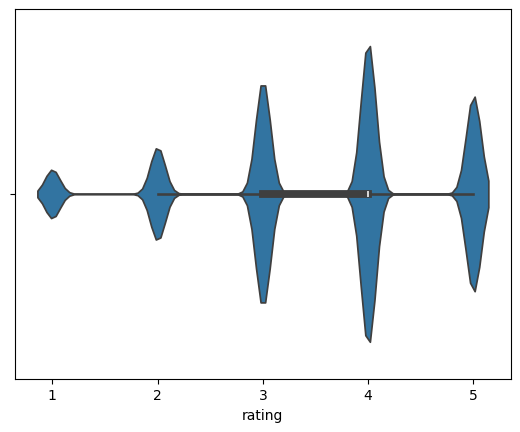

In [ ]:
sns.violinplot(
    x=ratings['rating']
)

==========================|QQ Plot|=========================

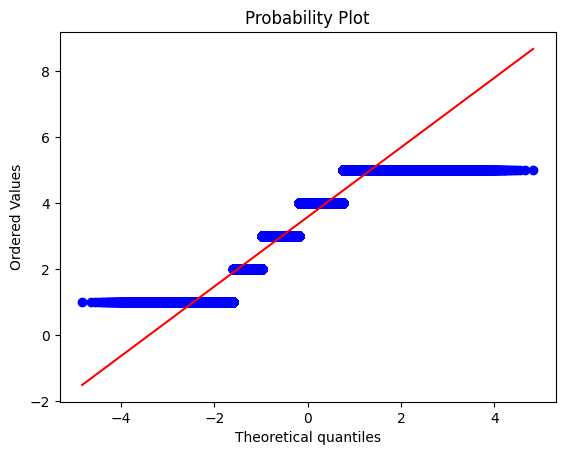

In [ ]:
from scipy import stats

stats.probplot(
    ratings['rating'],
    dist='norm',
    plot=plt
)

plt.show()

==========================|User Activity Histogram|=========================

(array([2.298e+03, 1.063e+03, 6.880e+02, 4.420e+02, 3.240e+02, 2.330e+02,
        2.170e+02, 1.290e+02, 1.320e+02, 8.000e+01, 8.400e+01, 6.500e+01,
        4.400e+01, 3.700e+01, 3.400e+01, 3.200e+01, 2.600e+01, 2.300e+01,
        2.300e+01, 1.200e+01, 1.100e+01, 1.100e+01, 3.000e+00, 2.000e+00,
        3.000e+00, 3.000e+00, 8.000e+00, 5.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([  20.  ,   65.88,  111.76,  157.64,  203.52,  249.4 ,  295.28,
         341.16,  387.04,  432.92,  478.8 ,  524.68,  570.56,  616.44,
         662.32,  708.2 ,  754.08,  799.96,  845.84,  891.72,  937.6 ,
         983.48, 1029.36, 1075.24, 1121.12, 1167.  , 1212.88, 1258.76,
        1304.64, 1350.52, 1396.4 , 1442.28, 1488.16, 1534.04, 1579.92,
        1625.8 , 1671

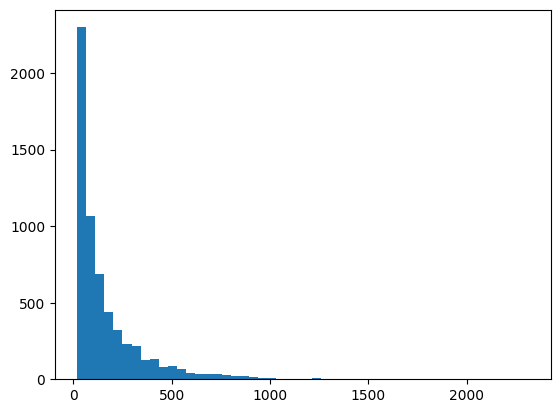

In [ ]:
plt.hist(
    user_counts,
    bins=50
)

==========================|User Activity Boxplott|=========================

<Axes: xlabel='None'>

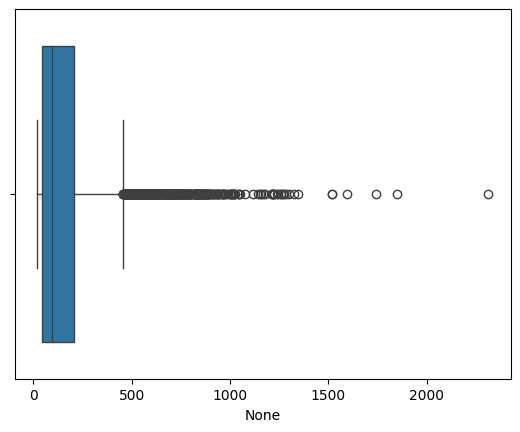

In [ ]:
sns.boxplot(
    x=user_counts
)

==========================|Movie Popularity Histogram|=========================

(array([1.436e+03, 5.070e+02, 3.710e+02, 2.670e+02, 1.770e+02, 1.720e+02,
        1.330e+02, 8.400e+01, 7.600e+01, 7.400e+01, 5.900e+01, 5.100e+01,
        4.000e+01, 3.300e+01, 3.000e+01, 2.900e+01, 3.000e+01, 1.600e+01,
        1.100e+01, 2.100e+01, 1.400e+01, 8.000e+00, 8.000e+00, 4.000e+00,
        8.000e+00, 9.000e+00, 4.000e+00, 0.000e+00, 1.000e+00, 3.000e+00,
        2.000e+00, 3.000e+00, 4.000e+00, 5.000e+00, 1.000e+00, 2.000e+00,
        2.000e+00, 4.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([1.00000e+00, 6.95400e+01, 1.38080e+02, 2.06620e+02, 2.75160e+02,
        3.43700e+02, 4.12240e+02, 4.80780e+02, 5.49320e+02, 6.17860e+02,
        6.86400e+02, 7.54940e+02, 8.23480e+02, 8.92020e+02, 9.60560e+02,
        1.02910e+03, 1.09764e+03, 1.16618e+03, 1.23472e+03, 1.30326e+03,
        1.37180e+03, 1.44034e+03, 1.50888e+03, 1.57742e+03, 1.64596e+03,
        1.7

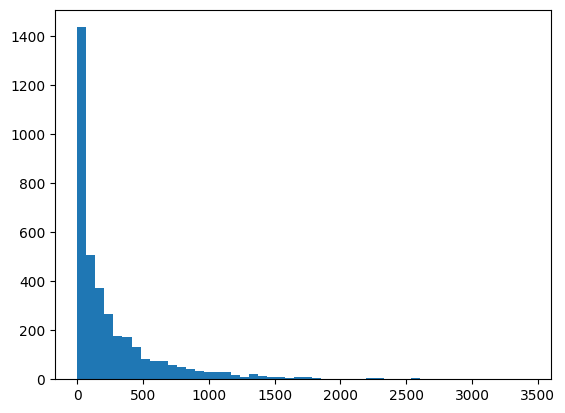

In [ ]:
plt.hist(
    movie_counts,
    bins=50
)

==========================|Movie Popularity Boxplot|=========================

<Axes: xlabel='None'>

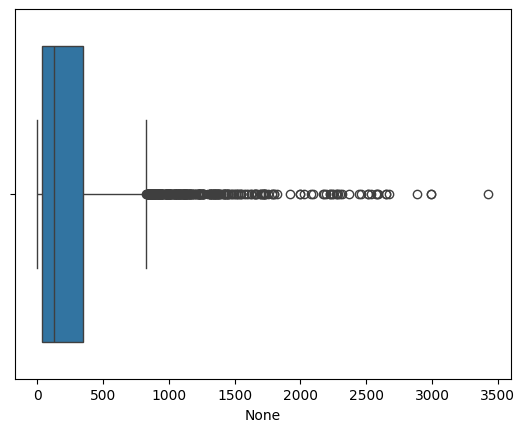

In [ ]:
sns.boxplot(
    x=movie_counts
)

==========================|Scatterplot (Age vs Rating)|=========================

<Axes: xlabel='age', ylabel='rating'>

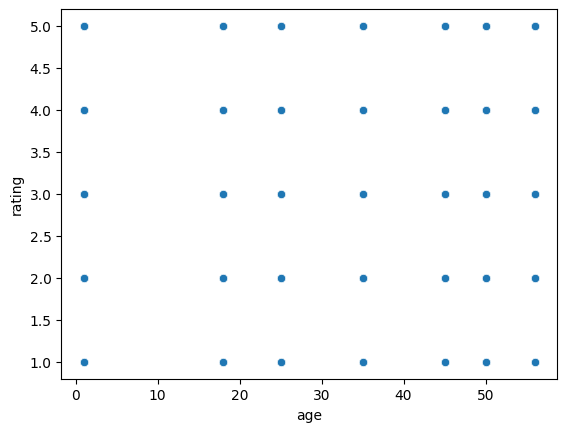

In [ ]:
sns.scatterplot(
    x='age',
    y='rating',
    data=data
)

==========================|Pair Plot|=========================

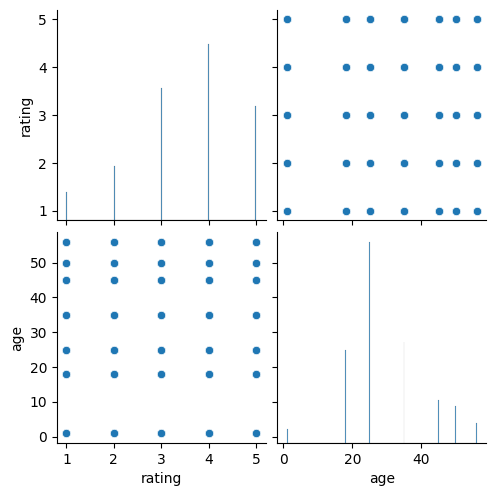

In [ ]:
sns.pairplot(
    data[['rating','age']]
)

==========================|Rating by Gender Boxplot|=========================

<Axes: xlabel='gender', ylabel='rating'>

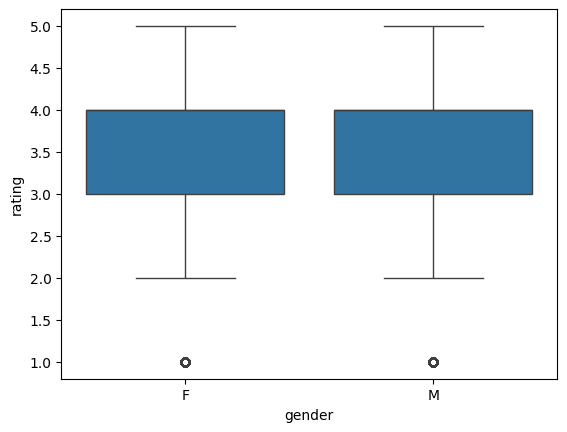

In [ ]:
sns.boxplot(
    x='gender',
    y='rating',
    data=data
)

==========================|Rating by Age Boxplot|=========================

<Axes: xlabel='age', ylabel='rating'>

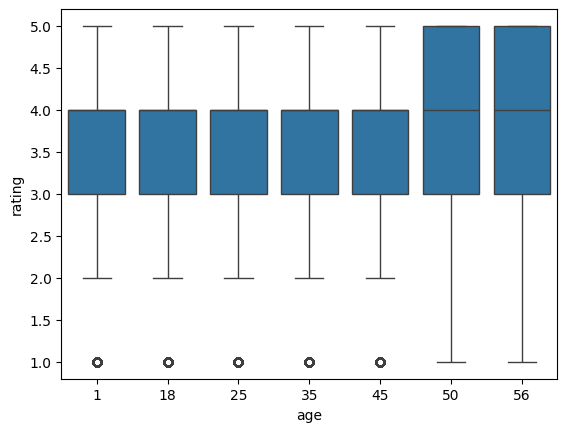

In [ ]:
sns.boxplot(
    x='age',
    y='rating',
    data=data
)

==========================|Rating by Gender Violin Plot|=========================

<Axes: xlabel='gender', ylabel='rating'>

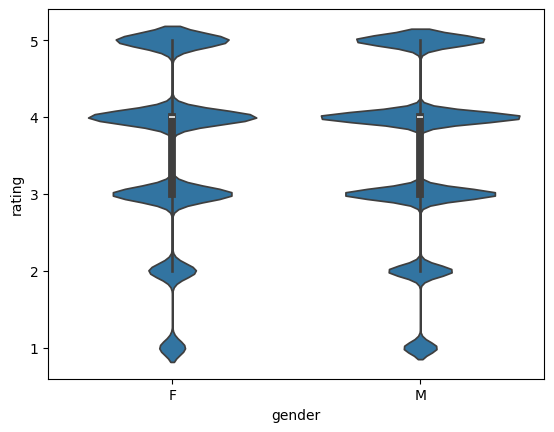

In [ ]:
sns.violinplot(
    x='gender',
    y='rating',
    data=data
)

==========================|Rating by Age Violin Plot|=========================

<Axes: xlabel='age', ylabel='rating'>

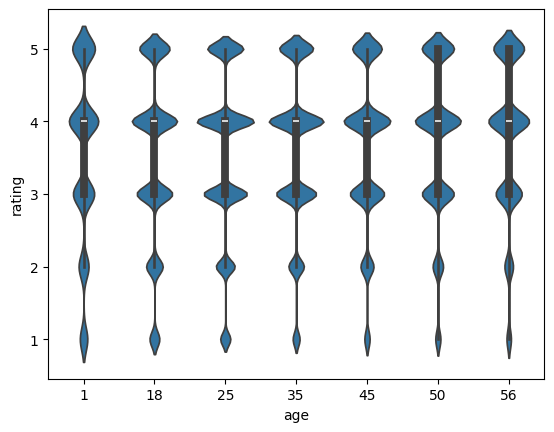

In [ ]:
sns.violinplot(
    x='age',
    y='rating',
    data=data
)

==========================|Crosstab Heatmap|=========================

<Axes: xlabel='occupation', ylabel='gender'>

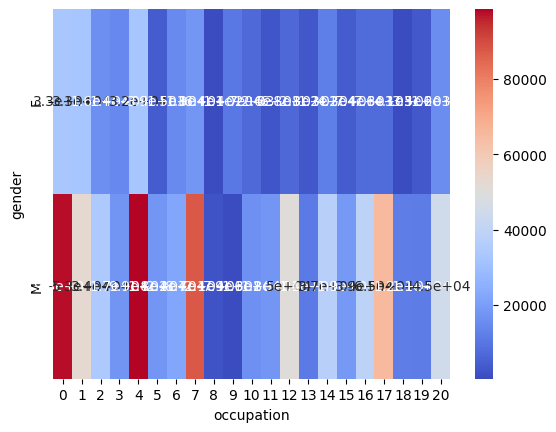

In [ ]:
sns.heatmap(
    gender_occ,
    annot=True,
    cmap='coolwarm'
)

==========================|Ratings Over Time Plot|=========================

<Axes: xlabel='Date'>

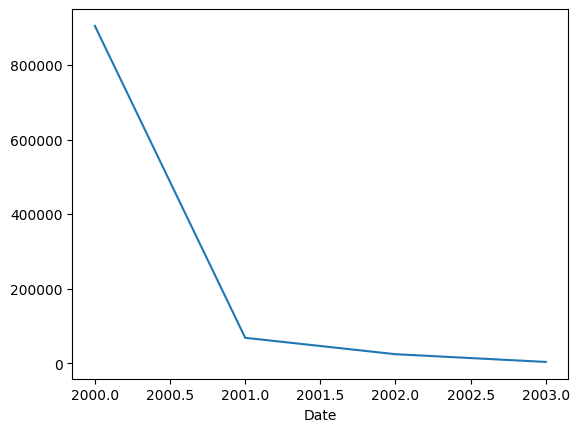

In [ ]:
ratings.groupby(
    ratings['Date'].dt.year
).size().plot()

==========================|Average Rating Over Time Plot|=========================

<Axes: xlabel='Date'>

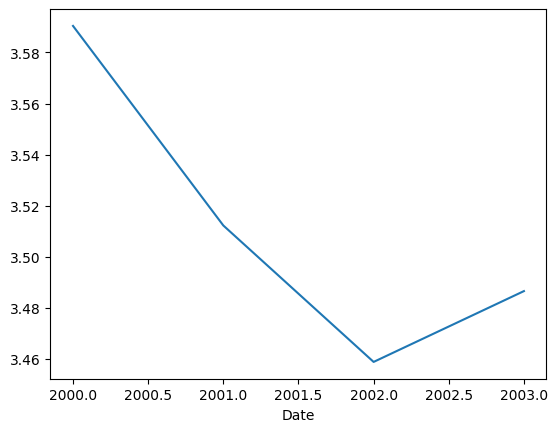

In [ ]:
ratings.groupby(
    ratings['Date'].dt.year
)['rating'].mean().plot()

==========================|Genre Rating Boxplots|=========================

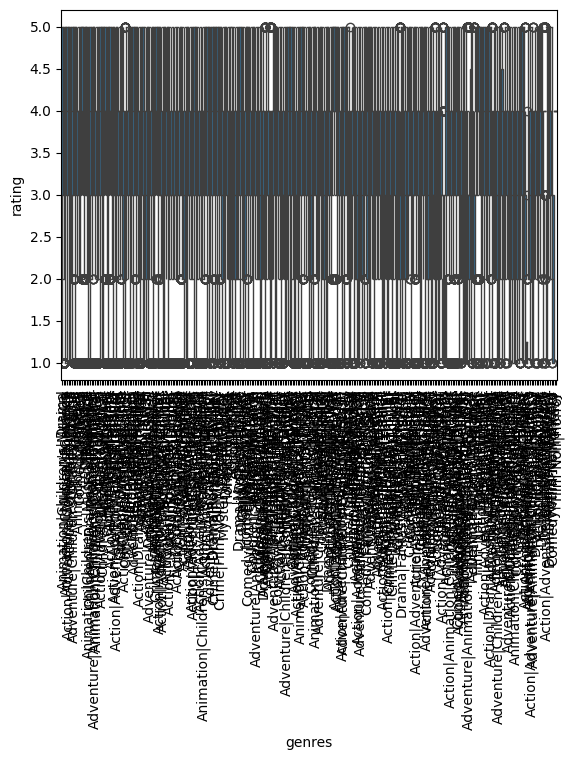

In [ ]:
sns.boxplot(
    x='genres',
    y='rating',
    data=data
)

plt.xticks(rotation=90)
plt.show()